``ModelEvaluatorPlot.scores`` draws the cross-validated scores from ``ModelEvaluator.run`` as grouped bars with confidence-interval error bars. First, the dataset, feature matrix, and evaluation:

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

# DOM_GSEC example dataset + a small feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Build the CPP feature matrix X
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

me = aa.ModelEvaluator(models=["rf", "svm"], random_state=42, verbose=False)
df_eval = me.run(X, labels, n_rounds=3)

/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programm

Plot ``df_eval`` with a ``figsize``, per-model ``colors``, and an explicit ``metrics`` order:

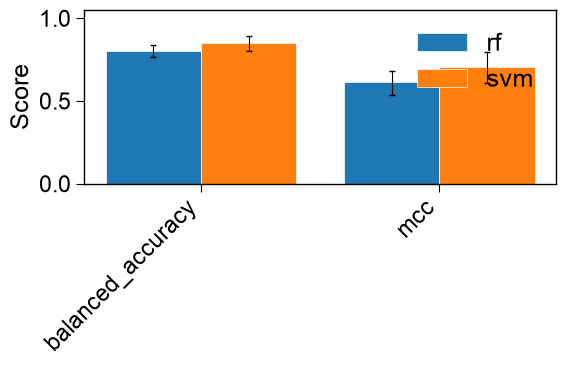

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
fig, ax = aa.ModelEvaluatorPlot.scores(df_eval=df_eval, figsize=(6, 4),
                                       colors=["tab:blue", "tab:orange"],
                                       metrics=["balanced_accuracy", "mcc"])
plt.tight_layout()
plt.show()